# TSA vs TDAH+TDA - Comparaison de classifieurs

**Input** : `output_final_cols.xlsx` | **Cible** : 1 = TSA, 0 = TDAH+TDA (sur `diag1` seul, sans TND/Sd Dys.)

---

## Plan en deux temps

**Partie A - Comparaison approfondie des 3 classifieurs** (LogReg / SVM / CatBoost)
- ROC + Precision-Recall + calibration interactives
- Stabilite multi-seeds, bootstrap des AUC, comparaison par paires
- Threshold sweep (sensibilite/specificite/F1 vs seuil)
- Importance des variables (coefficients, gain CatBoost, permutation pour SVM)

**Partie B - **
- Selection du modele final justifiee
- Decision curve analysis (net benefit)
- Scenarios de seuil (oriente sensibilite vs oriente specificite)
- Stratification en 3 groupes de risque
- Outil patient-par-patient + exemples
- Recommandations operationnelles

## 1 - Configuration

In [1]:
import os, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict, RepeatedStratifiedKFold
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             precision_recall_curve, average_precision_score,
                             classification_report,
                             brier_score_loss, accuracy_score, f1_score,
                             recall_score, precision_score)
from catboost import CatBoostClassifier
warnings.filterwarnings('ignore')

PALETTE = {
    'TSA':       '#2E86AB', 'TDAH+TDA':  '#E63946',
    'LogReg':    '#6A4C93', 'SVM':       '#F4A261', 'CatBoost':  '#06A77D',
    'bg':        '#F8FAFC', 'fg':        '#1F2937', 'muted':     '#94A3B8',
    'good':      '#10B981', 'warn':      '#F59E0B', 'bad':       '#EF4444',
}

def hex_to_rgba(h, a=0.20):
    return f'rgba({int(h[1:3],16)},{int(h[3:5],16)},{int(h[5:7],16)},{a})'

CMAP_DIV = LinearSegmentedColormap.from_list(
    'tsa_tdah', ['#E63946', '#FCA5A5', '#F8FAFC', '#93C5FD', '#2E86AB'], N=256)

sns.set_theme(style='whitegrid', context='notebook')
mpl.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 170, 'figure.facecolor': 'white',
    'axes.facecolor': '#FDFEFE',
    'axes.titlesize': 16, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'axes.labelsize': 13.5, 'axes.labelweight': 'semibold', 'axes.labelpad': 8,
    'axes.edgecolor': '#CBD5E1', 'axes.linewidth': 0.9,
    'axes.grid': True, 'grid.color': '#E2E8F0', 'grid.linewidth': 0.7,
    'xtick.labelsize': 11.5, 'ytick.labelsize': 11.5,
    'legend.fontsize': 12, 'legend.title_fontsize': 12.5,
    'legend.frameon': True, 'legend.facecolor': 'white',
    'legend.edgecolor': '#CBD5E1', 'legend.borderpad': 0.6,
    'xtick.color': '#475569', 'ytick.color': '#475569',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'font.size': 12,
    'figure.titlesize': 18, 'figure.titleweight': 'bold',
})

pio.templates['clinico'] = go.layout.Template(layout=go.Layout(
    font=dict(family='Segoe UI, Arial', size=14, color=PALETTE['fg']),
    paper_bgcolor='white', plot_bgcolor=PALETTE['bg'],
    title=dict(font=dict(size=19, color=PALETTE['fg']), x=0.02, xanchor='left'),
    xaxis=dict(gridcolor='#E2E8F0', zerolinecolor='#CBD5E1', linecolor='#94A3B8',
               title=dict(font=dict(size=14)), tickfont=dict(size=12)),
    yaxis=dict(gridcolor='#E2E8F0', zerolinecolor='#CBD5E1', linecolor='#94A3B8',
               title=dict(font=dict(size=14)), tickfont=dict(size=12)),
    legend=dict(bgcolor='rgba(255,255,255,0.92)', bordercolor='#CBD5E1', borderwidth=1,
                font=dict(size=13)),
    margin=dict(l=75, r=40, t=95, b=80)))
pio.templates.default = 'clinico'

def style_subplot_titles(fig, size=15):
    if fig.layout.annotations:
        for ann in fig.layout.annotations:
            ann.font = dict(size=size, color=PALETTE['fg'], family='Segoe UI, Arial')

RNG = np.random.default_rng(seed=42)
RANDOM_STATE = 42

OUT = Path('resultats_notebook'); OUT.mkdir(exist_ok=True)
print(f'Configuration prete - exports : {OUT.resolve()}')


Configuration prete - exports : C:\Users\Etudiant\Desktop\Regression logistic\resultats_notebook


## 2 - Donnees & cible

In [2]:
FICHIER = r'output_final_cols.xlsx'
df_raw = pd.read_excel(FICHIER)
df_raw.columns = [c.replace('\ufffd', '') for c in df_raw.columns]
renommage = {
    'sujet n': 'id', 'sexe_biologique (M/F)': 'sexe', 'age': 'age',
    'wais4_qi_total': 'QI', 'wais4_ivc': 'ICV', 'wais4_irp': 'IRP',
    'wais4_imt': 'IMT', 'wais4_ivt': 'IVT',
    'bcs_reco_total(1-60)': 'BCS_reco_total',
    'bcs_reco_erreur_colere(1-10)': 'BCS_err_colere',
    'bcs_reco_erreur_joie(1-10)': 'BCS_err_joie',
    'bcs_reco_erreur_degout(1-10)': 'BCS_err_degout',
    'bcs_reco_erreur_peur(1-10)': 'BCS_err_peur',
    'bcs_reco_erreur_surprise(1-10)': 'BCS_err_surprise',
    'bcs_reco_erreur_tristesse(1-10)': 'BCS_err_tristesse',
    'bcs_langyeux_score(1-33)': 'EyesTest',
    'tom_total': 'TOM_total', 'tom_fo': 'TOM_FO',
    'tom_so': 'TOM_SO', 'tom_fp': 'TOM_FP',
}
df = df_raw.rename(columns=renommage)
df = df[[c for c in renommage.values() if c in df.columns] + ['diag1', 'diag2', 'diag3']]
for c in ['diag1', 'diag2', 'diag3']:
    df[c] = df[c].astype(str).str.strip()
    df.loc[df[c].isin(['nan', 'None', '']), c] = np.nan

def categoriser(d1):
    if d1 in ('TDAH', 'TDA'): return 'TDAH+TDA'
    if d1 == 'TSA':           return 'TSA'
    return np.nan

df['groupe'] = df['diag1'].apply(categoriser)
df_an = df.dropna(subset=['groupe']).copy()
df_an['cible'] = (df_an['groupe'] == 'TSA').astype(int)
df_an['sexe_M'] = (df_an['sexe'].astype(str).str.upper() == 'M').astype(int)
df_an.loc[df_an['sexe'].isna(), 'sexe_M'] = np.nan

vars_num = ['QI', 'ICV', 'IRP', 'IMT', 'IVT',
            'BCS_reco_total', 'BCS_err_colere', 'BCS_err_joie', 'BCS_err_degout',
            'BCS_err_peur', 'BCS_err_surprise', 'BCS_err_tristesse',
            'EyesTest', 'TOM_total', 'TOM_FO', 'TOM_SO', 'TOM_FP']
FEATURES = vars_num + ['sexe_M']

X = df_an[FEATURES].copy()
y = df_an['cible'].values
n_pos = int(y.sum()); n_neg = int((1-y).sum())
prev = n_pos / len(y)

print(f'Cohorte d analyse : {len(df_an)} patients  |  {len(FEATURES)} variables')
print(f'  TSA        : {n_pos:3d}  ({prev*100:.1f}%)')
print(f'  TDAH+TDA   : {n_neg:3d}  ({(1-prev)*100:.1f}%)')
print(f'  Prevalence (= y=1) : {prev:.3f}')

Cohorte d analyse : 293 patients  |  18 variables
  TSA        :  78  (26.6%)
  TDAH+TDA   : 215  (73.4%)
  Prevalence (= y=1) : 0.266


# PARTIE A - Comparaison approfondie des 3 classifieurs

Objectif : evaluer **rigoureusement** lequel des 3 classifieurs offre la meilleure performance et la meilleure stabilite sur cette cohorte, et caracteriser leurs profils respectifs.

## A.1 - Pipelines et schema de validation

- **LogReg** : L2, `class_weight='balanced'`, scaler standard, imputation mediane
- **SVM (RBF)** : C=1, gamma='scale', `class_weight='balanced'`, probabilites calibrees (Platt)
- **CatBoost** : 400 iter., profondeur 4, lr 0.05, `auto_class_weights='Balanced'`, gere les NaN nativement

**Validation** : `RepeatedStratifiedKFold(n_splits=5, n_repeats=5)` => 25 estimations independantes par modele.

In [3]:
def make_pipelines():
    return {
        'LogReg': Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  StandardScaler()),
            ('clf', LogisticRegression(penalty='l2', C=1.0, solver='liblinear',
                                       class_weight='balanced', max_iter=2000,
                                       random_state=RANDOM_STATE))]),
        'SVM': Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  StandardScaler()),
            ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                        class_weight='balanced', probability=True,
                        random_state=RANDOM_STATE))]),
        'CatBoost': Pipeline([
            ('clf', CatBoostClassifier(iterations=400, depth=4, learning_rate=0.05,
                                       l2_leaf_reg=3.0, random_state=RANDOM_STATE,
                                       auto_class_weights='Balanced', verbose=False))]),
    }

MODELS = list(make_pipelines().keys())
print(f'Modeles : {MODELS}')

Modeles : ['LogReg', 'SVM', 'CatBoost']


In [4]:
# === Predictions cross-validees (5 folds, 1 repeat) pour les courbes / matrices ===
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
probas = {}
for name, pipe in make_pipelines().items():
    probas[name] = cross_val_predict(pipe, X, y, cv=cv5, method='predict_proba')[:, 1]

# === Stabilite : 25 estimations (5x5) ===
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
fold_metrics = {n: [] for n in MODELS}
for tr, te in rcv.split(X, y):
    for name, pipe in make_pipelines().items():
        pipe.fit(X.iloc[tr], y[tr])
        proba_te = pipe.predict_proba(X.iloc[te])[:, 1]
        pred_te  = (proba_te >= 0.5).astype(int)
        fold_metrics[name].append({
            'AUC':   roc_auc_score(y[te], proba_te),
            'AP':    average_precision_score(y[te], proba_te),
            'Brier': brier_score_loss(y[te], proba_te),
            'F1':    f1_score(y[te], pred_te),
            'Sens':  recall_score(y[te], pred_te),
            'Spec':  recall_score(y[te], pred_te, pos_label=0),
            'Acc':   accuracy_score(y[te], pred_te),
        })
fm = {n: pd.DataFrame(v) for n, v in fold_metrics.items()}
summary_rows = []
for n, dfm in fm.items():
    for m in ['AUC', 'AP', 'Brier', 'F1', 'Sens', 'Spec', 'Acc']:
        summary_rows.append({'modele': n, 'metric': m,
                              'mean': dfm[m].mean(), 'std': dfm[m].std(),
                              'q05': dfm[m].quantile(0.05), 'q95': dfm[m].quantile(0.95)})
summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT/'A1_metrics_repeated_cv.csv', index=False)
summary.pivot(index='modele', columns='metric', values='mean').round(3)

metric,AP,AUC,Acc,Brier,F1,Sens,Spec
modele,,,,,,,
CatBoost,0.614,0.792,0.761,0.168,0.524,0.500,0.856
LogReg,0.622,0.788,0.725,0.186,0.567,0.686,0.740
SVM,0.511,0.713,0.748,0.175,0.230,0.147,0.966


## A.2 - ROC + Precision-Recall + Calibration (interactif)

In [5]:
fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.13,
                    subplot_titles=('Courbes ROC (CV 5-fold)',
                                    f'Precision-Recall (prevalence TSA = {prev:.2f})',
                                    'Calibration des probabilites'))

for name, p in probas.items():
    fpr, tpr, thr = roc_curve(y, p)
    auc = roc_auc_score(y, p)
    youden = tpr - fpr; i_opt = int(np.argmax(youden))
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr, mode='lines', name=f'{name} (AUC={auc:.3f})',
        line=dict(color=PALETTE[name], width=3.5),
        legendgroup=name,
        hovertemplate=f'<b>{name}</b><br>1-Spec=%{{x:.3f}}  Sens=%{{y:.3f}}<extra></extra>'),
        row=1, col=1)
    fig.add_trace(go.Scatter(
        x=[fpr[i_opt]], y=[tpr[i_opt]], mode='markers', showlegend=False,
        marker=dict(size=18, color=PALETTE[name], symbol='star',
                    line=dict(color='black', width=1.8)),
        legendgroup=name,
        hovertemplate=f'<b>{name}</b><br>Seuil Youden p={thr[i_opt]:.2f}<br>'
                      f'Sens={tpr[i_opt]:.2f}  Spec={1-fpr[i_opt]:.2f}<extra></extra>'),
        row=1, col=1)

    pr, rc, _ = precision_recall_curve(y, p)
    ap = average_precision_score(y, p)
    fig.add_trace(go.Scatter(
        x=rc, y=pr, mode='lines', name=f'{name} (AP={ap:.3f})',
        line=dict(color=PALETTE[name], width=3.5),
        legendgroup=name, showlegend=False,
        hovertemplate=f'<b>{name}</b><br>Recall=%{{x:.3f}}  Precision=%{{y:.3f}}<extra></extra>'),
        row=1, col=2)

    fp, mp = calibration_curve(y, p, n_bins=8, strategy='quantile')
    brier = brier_score_loss(y, p)
    fig.add_trace(go.Scatter(
        x=mp, y=fp, mode='lines+markers', name=f'{name} (Brier={brier:.3f})',
        line=dict(color=PALETTE[name], width=3),
        marker=dict(size=12, color=PALETTE[name], line=dict(color='white', width=1.8)),
        legendgroup=name, showlegend=False,
        hovertemplate=f'<b>{name}</b><br>p predite=%{{x:.2f}}  freq obs=%{{y:.2f}}<extra></extra>'),
        row=1, col=3)

# Reperes
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', showlegend=False,
                          line=dict(color=PALETTE['muted'], dash='dash', width=1.8),
                          hoverinfo='skip'), row=1, col=1)
fig.add_hline(y=prev, line=dict(color=PALETTE['muted'], dash='dash', width=1.8),
              annotation_text=f'prev={prev:.2f}',
              annotation_font=dict(size=13, color=PALETTE['muted']),
              annotation_position='bottom right',
              row=1, col=2)
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', showlegend=False,
                          line=dict(color=PALETTE['muted'], dash='dash', width=1.8),
                          hoverinfo='skip'), row=1, col=3)

fig.update_xaxes(title_text='1 - Specificite', range=[-0.02, 1.02], row=1, col=1)
fig.update_yaxes(title_text='Sensibilite', range=[-0.02, 1.02], row=1, col=1)
fig.update_xaxes(title_text='Recall (Sensibilite)', range=[-0.02, 1.02], row=1, col=2)
fig.update_yaxes(title_text='Precision (PPV)', range=[-0.02, 1.02], row=1, col=2)
fig.update_xaxes(title_text='Probabilite predite', range=[-0.02, 1.02], row=1, col=3)
fig.update_yaxes(title_text='Frequence observee TSA', range=[-0.02, 1.02], row=1, col=3)
fig.update_layout(height=640,
                  title=dict(text='<b>Performance des 3 classifieurs (CV 5-fold)</b><br>'
                                  '<sup style="font-size:13px">Etoile = seuil Youden. Survol = details</sup>',
                             font=dict(size=20)),
                  legend=dict(orientation='h', yanchor='bottom', y=-0.26,
                              xanchor='center', x=0.5, font=dict(size=14)),
                  margin=dict(l=80, r=40, t=110, b=110))
style_subplot_titles(fig, size=15)
fig.write_image(str(OUT/'A2_roc_pr_calibration.png'), width=1900, height=640, scale=2)
fig.show()


## A.3 - Stabilite : 25 estimations + bootstrap des AUC + comparaison par paires

- **Boxplot AUC** (25 valeurs cross-validees par modele)
- **Bootstrap stratifie 1000x** sur les predictions cross-validees -> IC95% pour chaque AUC
- **Test par paires** : difference d'AUC bootstrap (delta AUC) entre modeles avec IC95%

In [6]:
# Bootstrap stratifie des AUC sur la prediction cross-validee
def bootstrap_auc(y_true, y_score, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    pos = np.where(y_true == 1)[0]; neg = np.where(y_true == 0)[0]
    aucs = np.empty(n_boot)
    for i in range(n_boot):
        s_p = rng.choice(pos, size=len(pos), replace=True)
        s_n = rng.choice(neg, size=len(neg), replace=True)
        idx = np.concatenate([s_p, s_n])
        aucs[i] = roc_auc_score(y_true[idx], y_score[idx])
    return aucs

boot = {n: bootstrap_auc(y, probas[n], n_boot=1000, seed=42) for n in MODELS}
boot_ic = {n: (np.quantile(boot[n], 0.025), np.quantile(boot[n], 0.975)) for n in MODELS}

# Paired bootstrap : delta AUC entre modeles avec memes echantillons
def paired_delta_auc(y_true, score_a, score_b, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    pos = np.where(y_true == 1)[0]; neg = np.where(y_true == 0)[0]
    delta = np.empty(n_boot)
    for i in range(n_boot):
        s_p = rng.choice(pos, size=len(pos), replace=True)
        s_n = rng.choice(neg, size=len(neg), replace=True)
        idx = np.concatenate([s_p, s_n])
        delta[i] = roc_auc_score(y_true[idx], score_a[idx]) - roc_auc_score(y_true[idx], score_b[idx])
    return delta

pair_rows = []
for i, A in enumerate(MODELS):
    for B in MODELS[i+1:]:
        d = paired_delta_auc(y, probas[A], probas[B], n_boot=1000)
        # p-value : prop. d echantillons croisant 0 (test bilateral)
        pval = 2 * min((d <= 0).mean(), (d >= 0).mean())
        pair_rows.append({
            'A': A, 'B': B,
            'AUC_A': roc_auc_score(y, probas[A]),
            'AUC_B': roc_auc_score(y, probas[B]),
            'delta_AUC': d.mean(),
            'IC95_lo': np.quantile(d, 0.025),
            'IC95_hi': np.quantile(d, 0.975),
            'p_value': pval,
        })
pair_df = pd.DataFrame(pair_rows)
pair_df.to_csv(OUT/'A3_paired_bootstrap.csv', index=False)
print('=== Comparaison par paires (delta AUC = A - B) ===')
print(pair_df.round(4).to_string(index=False))

=== Comparaison par paires (delta AUC = A - B) ===
     A        B  AUC_A  AUC_B  delta_AUC  IC95_lo  IC95_hi  p_value
LogReg      SVM 0.7859 0.7084     0.0772   0.0354   0.1206    0.000
LogReg CatBoost 0.7859 0.8085    -0.0223  -0.0642   0.0227    0.326
   SVM CatBoost 0.7084 0.8085    -0.0995  -0.1426  -0.0602    0.000


In [7]:
# === Figure : box AUC (25 folds) + bootstrap densite + paired delta AUC ===
fig = make_subplots(rows=1, cols=3, column_widths=[0.34, 0.33, 0.33],
                    horizontal_spacing=0.14,
                    subplot_titles=('AUC sur 25 folds (5 splits x 5 repeats)',
                                    'Distribution bootstrap des AUC',
                                    'Comparaison par paires (delta AUC)'))

# 1 - Box 25 folds
for name in MODELS:
    fig.add_trace(go.Box(
        y=fm[name]['AUC'], name=name, boxpoints='all', jitter=0.4, pointpos=0,
        marker=dict(size=9, color=PALETTE[name], line=dict(color='white', width=1.4)),
        line=dict(color=PALETTE[name], width=3),
        fillcolor=hex_to_rgba(PALETTE[name], 0.25),
        showlegend=False,
        hovertemplate=f'<b>{name}</b><br>AUC = %{{y:.3f}}<extra></extra>'),
        row=1, col=1)

# 2 - Densites bootstrap (KDE)
from scipy.stats import gaussian_kde
x_grid = np.linspace(0.50, 1.00, 200)
for name in MODELS:
    kde = gaussian_kde(boot[name], bw_method=0.3)
    yk = kde(x_grid)
    lo, hi = boot_ic[name]
    mean = boot[name].mean()
    fig.add_trace(go.Scatter(
        x=x_grid, y=yk, mode='lines', name=name,
        line=dict(color=PALETTE[name], width=3),
        fill='tozeroy', fillcolor=hex_to_rgba(PALETTE[name], 0.20),
        hovertemplate=f'<b>{name}</b><br>AUC=%{{x:.3f}}<br>densite=%{{y:.2f}}<extra></extra>'),
        row=1, col=2)
    fig.add_vline(x=mean, line=dict(color=PALETTE[name], width=1.8, dash='dash'),
                  row=1, col=2)

# 3 - Paired delta AUC
for i, r in pair_df.iterrows():
    label = f'{r["A"]} - {r["B"]}'
    color = PALETTE['good'] if r['p_value'] < 0.05 else PALETTE['muted']
    fig.add_trace(go.Scatter(
        x=[r['IC95_lo'], r['IC95_hi']], y=[label, label],
        mode='lines', line=dict(color=color, width=4),
        showlegend=False, hoverinfo='skip'), row=1, col=3)
    sig = '*' if r['p_value'] < 0.05 else ''
    fig.add_trace(go.Scatter(
        x=[r['delta_AUC']], y=[label], mode='markers+text',
        marker=dict(size=18, color=color, line=dict(color='white', width=2.2)),
        text=[f'  {r["delta_AUC"]:+.3f} {sig}'], textposition='middle right',
        textfont=dict(size=13, color=PALETTE['fg']),
        showlegend=False,
        hovertemplate=(f'<b>{label}</b><br>'
                       f'delta AUC = {r["delta_AUC"]:+.3f}<br>'
                       f'IC95 = [{r["IC95_lo"]:+.3f}, {r["IC95_hi"]:+.3f}]<br>'
                       f'p = {r["p_value"]:.3f}<extra></extra>')),
        row=1, col=3)
fig.add_vline(x=0, line=dict(color='black', width=1.2), row=1, col=3)

fig.update_yaxes(title_text='AUC', range=[0.5, 1.0], row=1, col=1)
fig.update_xaxes(title_text='AUC', range=[0.5, 1.0], row=1, col=2)
fig.update_yaxes(title_text='densite', row=1, col=2)
fig.update_xaxes(title_text='delta AUC', row=1, col=3)
# Donne plus de place a droite pour les annotations textuelles
fig.update_xaxes(automargin=True, row=1, col=3)
fig.update_layout(height=620,
                  title=dict(text='<b>Stabilite des AUC et comparaison statistique</b>',
                             font=dict(size=20)),
                  showlegend=False,
                  margin=dict(l=80, r=80, t=110, b=80))
style_subplot_titles(fig, size=15)
fig.write_image(str(OUT/'A3_stability_paired.png'), width=1900, height=620, scale=2)
fig.show()

print('\nIC95 de l AUC (bootstrap 1000) :')
for n in MODELS:
    print(f'  {n:10s}  AUC = {roc_auc_score(y, probas[n]):.3f}  '
          f'IC95 = [{boot_ic[n][0]:.3f}, {boot_ic[n][1]:.3f}]')



IC95 de l AUC (bootstrap 1000) :
  LogReg      AUC = 0.786  IC95 = [0.726, 0.841]
  SVM         AUC = 0.708  IC95 = [0.640, 0.771]
  CatBoost    AUC = 0.808  IC95 = [0.748, 0.862]


## A.4 - Threshold sweep : sensibilite / specificite / F1 selon le seuil

Le seuil 0.5 par defaut n'est pas optimal sur une cohorte desequilibree. On trace **toutes** les metriques en fonction du seuil pour chaque modele.

In [8]:
thr_grid = np.linspace(0.05, 0.95, 91)
sweep = []
for name, p in probas.items():
    for t in thr_grid:
        pred = (p >= t).astype(int)
        if pred.sum() == 0 or pred.sum() == len(pred): continue
        sweep.append({
            'modele': name, 'thr': t,
            'Sens': recall_score(y, pred),
            'Spec': recall_score(y, pred, pos_label=0),
            'F1':   f1_score(y, pred),
            'Prec': precision_score(y, pred),
            'Acc':  accuracy_score(y, pred),
            'Youden': recall_score(y, pred) - (1 - recall_score(y, pred, pos_label=0)),
        })
sw = pd.DataFrame(sweep)

fig = make_subplots(rows=1, cols=3, subplot_titles=tuple(MODELS),
                    horizontal_spacing=0.10)
for i, name in enumerate(MODELS, start=1):
    sub = sw[sw['modele']==name]
    for col, metric in [(PALETTE['TSA'], 'Sens'),
                         (PALETTE['TDAH+TDA'], 'Spec'),
                         (PALETTE['CatBoost'], 'F1'),
                         (PALETTE['LogReg'], 'Youden')]:
        fig.add_trace(go.Scatter(
            x=sub['thr'], y=sub[metric], mode='lines',
            name=metric, line=dict(color=col, width=3),
            showlegend=(i==1), legendgroup=metric,
            hovertemplate=f'<b>{name}</b><br>seuil=%{{x:.2f}}<br>{metric}=%{{y:.3f}}<extra></extra>'),
            row=1, col=i)
    # Seuil Youden optimal
    t_y = sub.loc[sub['Youden'].idxmax(), 'thr']
    fig.add_vline(x=t_y, line=dict(color='black', width=1.8, dash='dot'),
                  annotation_text=f'Youden {t_y:.2f}',
                  annotation_font=dict(size=12, color=PALETTE['fg']),
                  annotation_position='top right' if i<3 else 'top left',
                  row=1, col=i)
    fig.update_xaxes(title_text='Seuil de probabilite', row=1, col=i)
    fig.update_yaxes(title_text='valeur metrique' if i==1 else '', range=[0,1], row=1, col=i)

fig.update_layout(height=580,
                  title=dict(text='<b>Compromis Sensibilite / Specificite / F1 selon le seuil</b>',
                             font=dict(size=20)),
                  legend=dict(orientation='h', yanchor='bottom', y=-0.24,
                              xanchor='center', x=0.5, font=dict(size=14)),
                  margin=dict(l=80, r=40, t=110, b=110))
style_subplot_titles(fig, size=15)
fig.write_image(str(OUT/'A4_threshold_sweep.png'), width=1900, height=580, scale=2)
fig.show()


## A.5 - Matrices de confusion a 3 seuils (defaut / Youden / haute sensibilite)

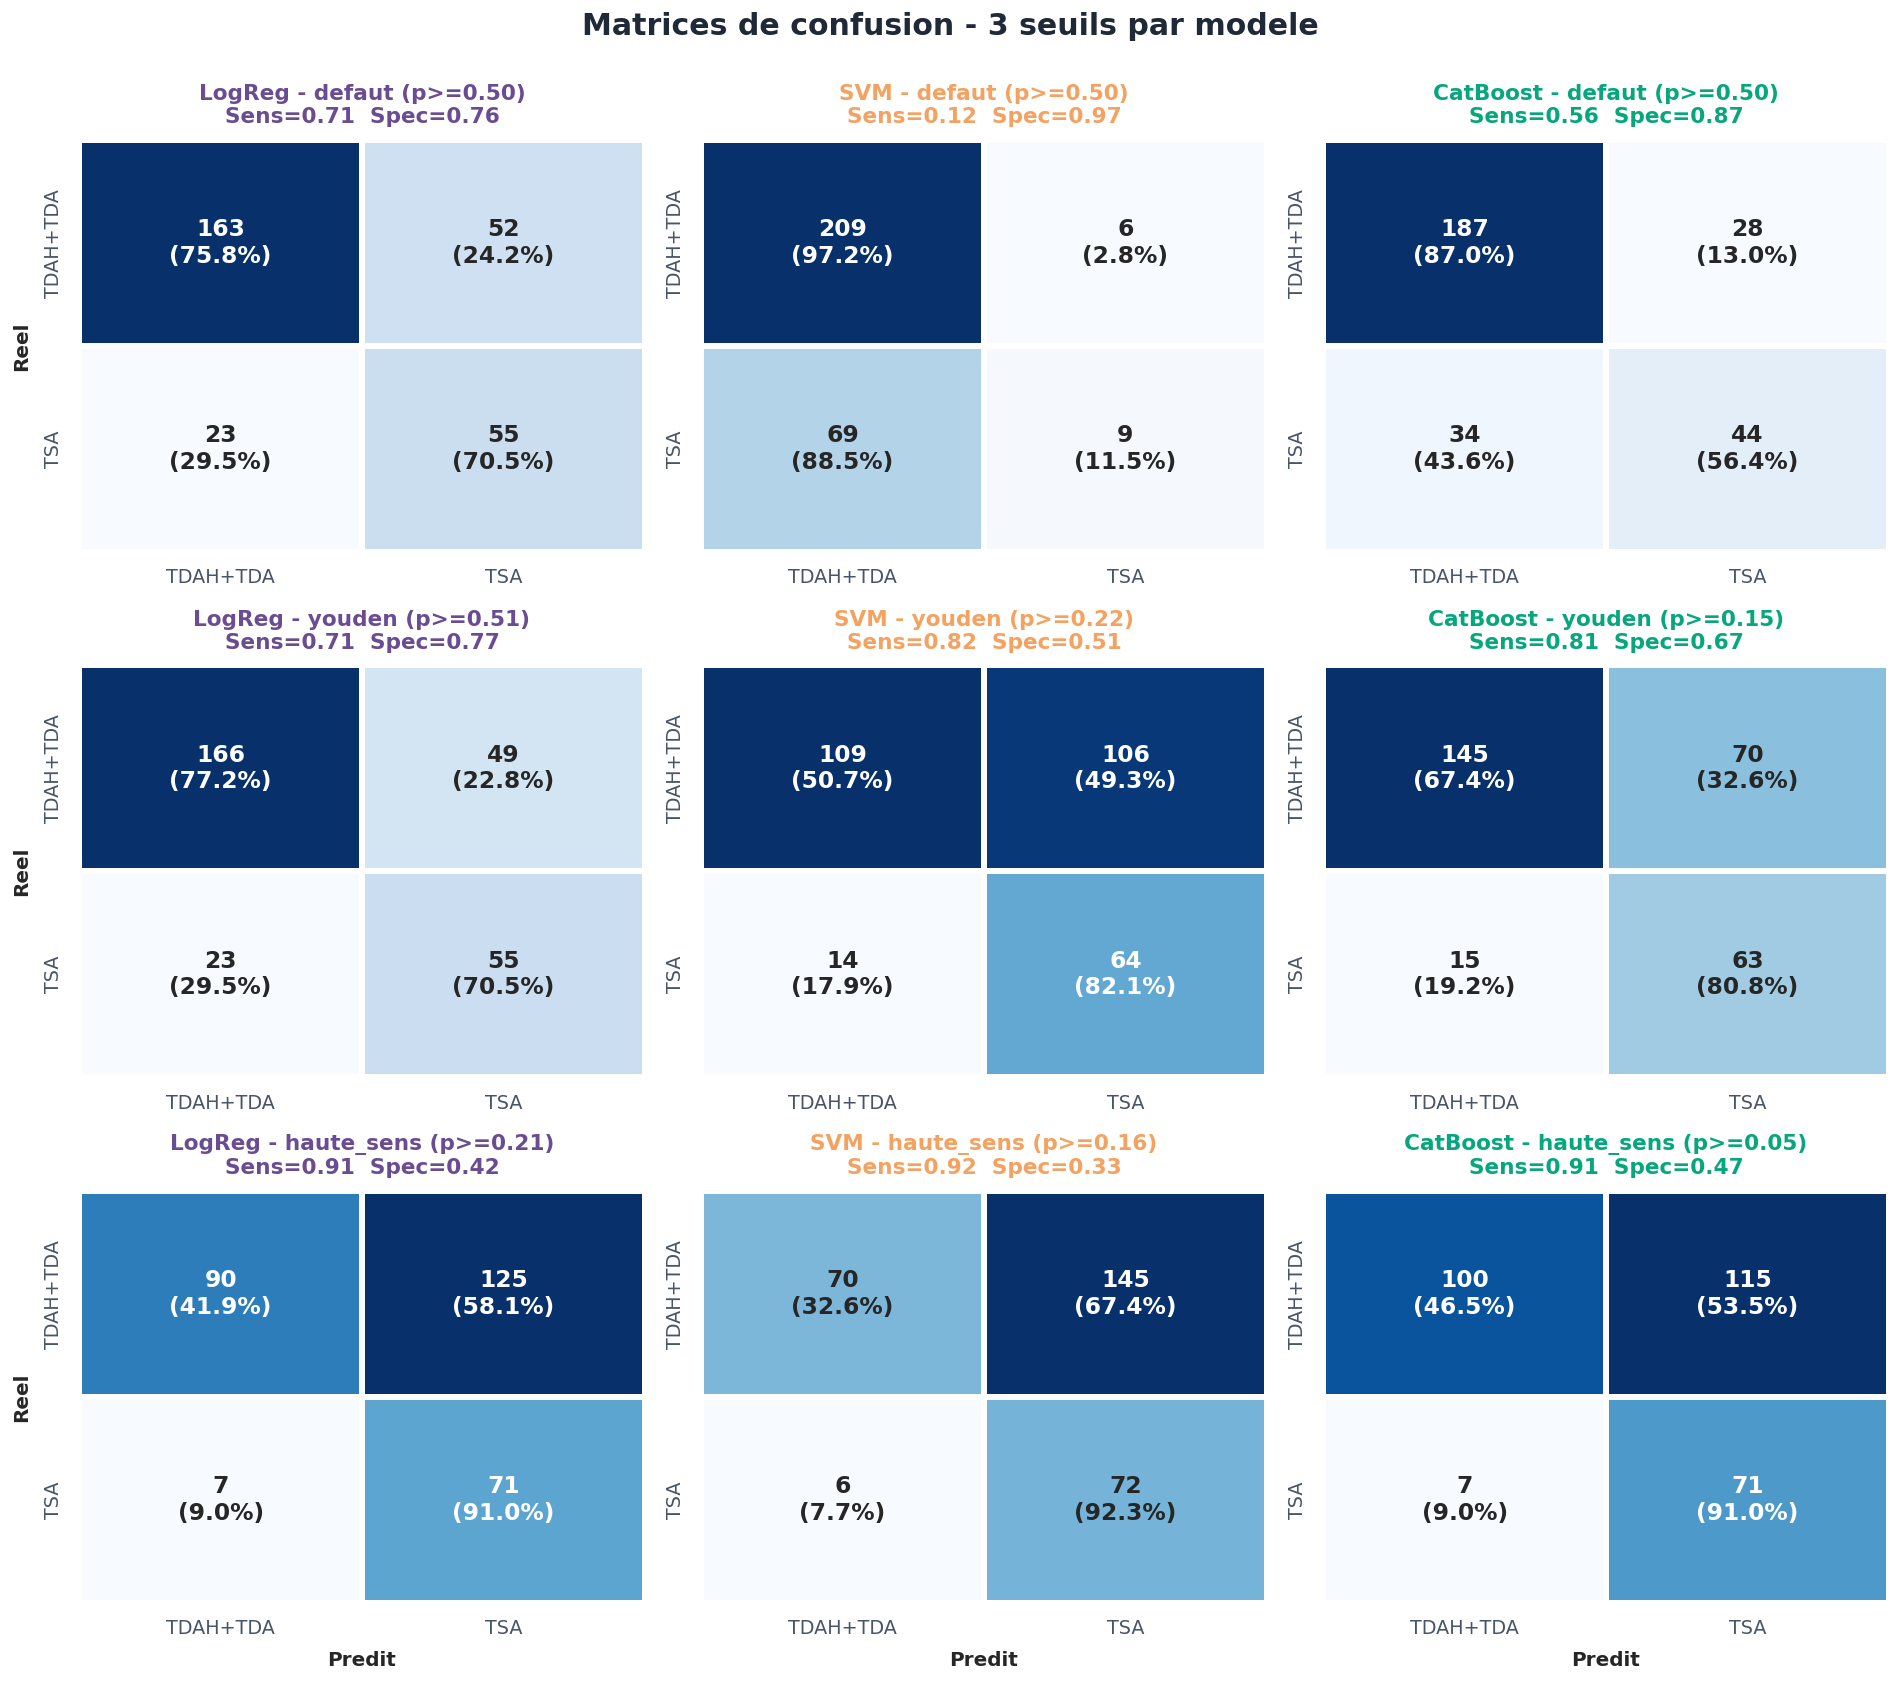

In [9]:
thresholds_compare = {}
for name, p in probas.items():
    fpr, tpr, thr = roc_curve(y, p)
    t_youden = thr[np.argmax(tpr - fpr)]
    mask = tpr >= 0.90
    t_hsens = thr[np.where(mask)[0].min()] if mask.any() else thr[-1]
    thresholds_compare[name] = {'defaut': 0.5, 'youden': float(t_youden), 'haute_sens': float(t_hsens)}

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ci, name in enumerate(MODELS):
    p = probas[name]
    for ri, (label, thr) in enumerate(thresholds_compare[name].items()):
        ax = axes[ri, ci]
        pred = (p >= thr).astype(int)
        cm = confusion_matrix(y, pred)
        cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
        annot = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
        sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['TDAH+TDA', 'TSA'], yticklabels=['TDAH+TDA', 'TSA'],
                    linewidths=2.5, linecolor='white',
                    annot_kws={'fontsize': 14, 'fontweight': 'bold'})
        sens = recall_score(y, pred); spec = recall_score(y, pred, pos_label=0)
        ax.set_title(f'{name} - {label} (p>={thr:.2f})\n'
                      f'Sens={sens:.2f}  Spec={spec:.2f}',
                      color=PALETTE[name], fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel('Predit' if ri==2 else '', fontsize=12)
        ax.set_ylabel('Reel' if ci==0 else '', fontsize=12)
        ax.tick_params(axis='both', labelsize=11.5)
plt.suptitle('Matrices de confusion - 3 seuils par modele',
             fontsize=18, fontweight='bold', y=1.00, color=PALETTE['fg'])
plt.tight_layout(); plt.savefig(OUT/'A5_confusion_3seuils.png', bbox_inches='tight'); plt.show()


## A.6 - Importance des variables (3 modeles + permutation pour SVM)

In [10]:
lr_pipe = make_pipelines()['LogReg']; lr_pipe.fit(X, y)
lr_imp = pd.DataFrame({'feature': FEATURES,
                       'coef': lr_pipe.named_steps['clf'].coef_[0]}).assign(
                           abs_coef=lambda d: d['coef'].abs()).sort_values('abs_coef', ascending=False)

cb_pipe = make_pipelines()['CatBoost']; cb_pipe.fit(X, y)
cb_imp = pd.DataFrame({'feature': FEATURES,
                       'importance': cb_pipe.named_steps['clf'].get_feature_importance()}
                       ).sort_values('importance', ascending=False)

# SVM : permutation importance sur un fold
from sklearn.model_selection import train_test_split as tts
X_tr, X_te, y_tr, y_te = tts(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
svm_pipe = make_pipelines()['SVM']; svm_pipe.fit(X_tr, y_tr)
perm = permutation_importance(svm_pipe, X_te, y_te, n_repeats=20,
                                random_state=RANDOM_STATE, scoring='roc_auc')
svm_imp = pd.DataFrame({'feature': FEATURES,
                        'perm_AUC_drop': perm.importances_mean,
                        'perm_std': perm.importances_std}).sort_values('perm_AUC_drop', ascending=False)

lr_imp.to_csv(OUT/'A6_logreg_coefficients.csv', index=False)
cb_imp.to_csv(OUT/'A6_catboost_importance.csv', index=False)
svm_imp.to_csv(OUT/'A6_svm_permutation.csv', index=False)

# Helper : ne montre le label que si la valeur est suffisamment grande (sinon vide)
def label_filtre(values, seuil, fmt):
    return [fmt.format(v) if abs(v) >= seuil else '' for v in values]

# Figure Plotly : 3 panneaux empiles verticalement (chaque panneau = pleine largeur)
fig = make_subplots(rows=3, cols=1, vertical_spacing=0.085,
                    subplot_titles=(
                        'LogReg - coefficients standardises  (rouge -> TDAH+TDA, bleu -> TSA)',
                        'SVM - permutation importance (drop AUC sur fold test)',
                        'CatBoost - feature importance (gain)'))

# --- Panneau 1 : LogReg ---
ord_lr = lr_imp.sort_values('coef')
colors_lr = [PALETTE['TSA'] if c > 0 else PALETTE['TDAH+TDA'] for c in ord_lr['coef']]
xmax_lr = max(abs(ord_lr['coef'].min()), abs(ord_lr['coef'].max())) * 1.30
fig.add_trace(go.Bar(
    x=ord_lr['coef'], y=ord_lr['feature'], orientation='h',
    marker=dict(color=colors_lr, line=dict(color='white', width=1.5)),
    text=label_filtre(ord_lr['coef'], seuil=0.03, fmt='{:+.2f}'),
    textposition='outside', textfont=dict(size=12, color=PALETTE['fg']),
    cliponaxis=False,
    showlegend=False,
    hovertemplate='<b>%{y}</b><br>coef = %{x:+.3f}<extra></extra>'),
    row=1, col=1)
fig.add_vline(x=0, line=dict(color='black', width=1.2), row=1, col=1)
fig.update_xaxes(title_text='coefficient (standardise)', row=1, col=1,
                 range=[-xmax_lr, xmax_lr], zeroline=True, zerolinewidth=1.2,
                 zerolinecolor='black')

# --- Panneau 2 : SVM ---
ord_sv = svm_imp.sort_values('perm_AUC_drop')
xmax_sv = (ord_sv['perm_AUC_drop'].max() + ord_sv['perm_std'].max()) * 1.55
xmin_sv = min(0, ord_sv['perm_AUC_drop'].min() - ord_sv['perm_std'].max()) * 1.30 - 0.005
fig.add_trace(go.Bar(
    x=ord_sv['perm_AUC_drop'], y=ord_sv['feature'], orientation='h',
    marker=dict(color=PALETTE['SVM'], line=dict(color='white', width=1.5)),
    error_x=dict(type='data', array=ord_sv['perm_std'], thickness=1.5,
                 color=PALETTE['fg'], width=4),
    text=label_filtre(ord_sv['perm_AUC_drop'], seuil=0.01, fmt='{:+.3f}'),
    textposition='outside', textfont=dict(size=12, color=PALETTE['fg']),
    cliponaxis=False,
    showlegend=False,
    hovertemplate='<b>%{y}</b><br>drop AUC = %{x:+.3f}<extra></extra>'),
    row=2, col=1)
fig.add_vline(x=0, line=dict(color='black', width=1.2), row=2, col=1)
fig.update_xaxes(title_text="diminution de l'AUC apres permutation  (valeurs <0.01 non annotees)",
                 row=2, col=1, range=[xmin_sv, xmax_sv])

# --- Panneau 3 : CatBoost ---
ord_cb = cb_imp.sort_values('importance')
xmax_cb = ord_cb['importance'].max() * 1.22
fig.add_trace(go.Bar(
    x=ord_cb['importance'], y=ord_cb['feature'], orientation='h',
    marker=dict(color=PALETTE['CatBoost'], line=dict(color='white', width=1.5)),
    text=label_filtre(ord_cb['importance'], seuil=0.3, fmt='{:.1f}'),
    textposition='outside', textfont=dict(size=12, color=PALETTE['fg']),
    cliponaxis=False,
    showlegend=False,
    hovertemplate='<b>%{y}</b><br>importance = %{x:.2f}<extra></extra>'),
    row=3, col=1)
fig.update_xaxes(title_text='importance (gain)', row=3, col=1, range=[0, xmax_cb])

fig.update_yaxes(tickfont=dict(size=12.5), automargin=True)
fig.update_layout(
    height=1450,
    title=dict(text='<b>Importance des variables - 3 modeles</b><br>'
                    '<sup style="font-size:13px">Chaque panneau classe les variables de la moins a la plus discriminante pour son modele</sup>',
               font=dict(size=21), x=0.02, xanchor='left'),
    showlegend=False,
    margin=dict(l=170, r=130, t=130, b=70),
    bargap=0.30,
)
style_subplot_titles(fig, size=15)
fig.write_image(str(OUT/'A6_importance_3models.png'), width=1500, height=1450, scale=2)
fig.show()


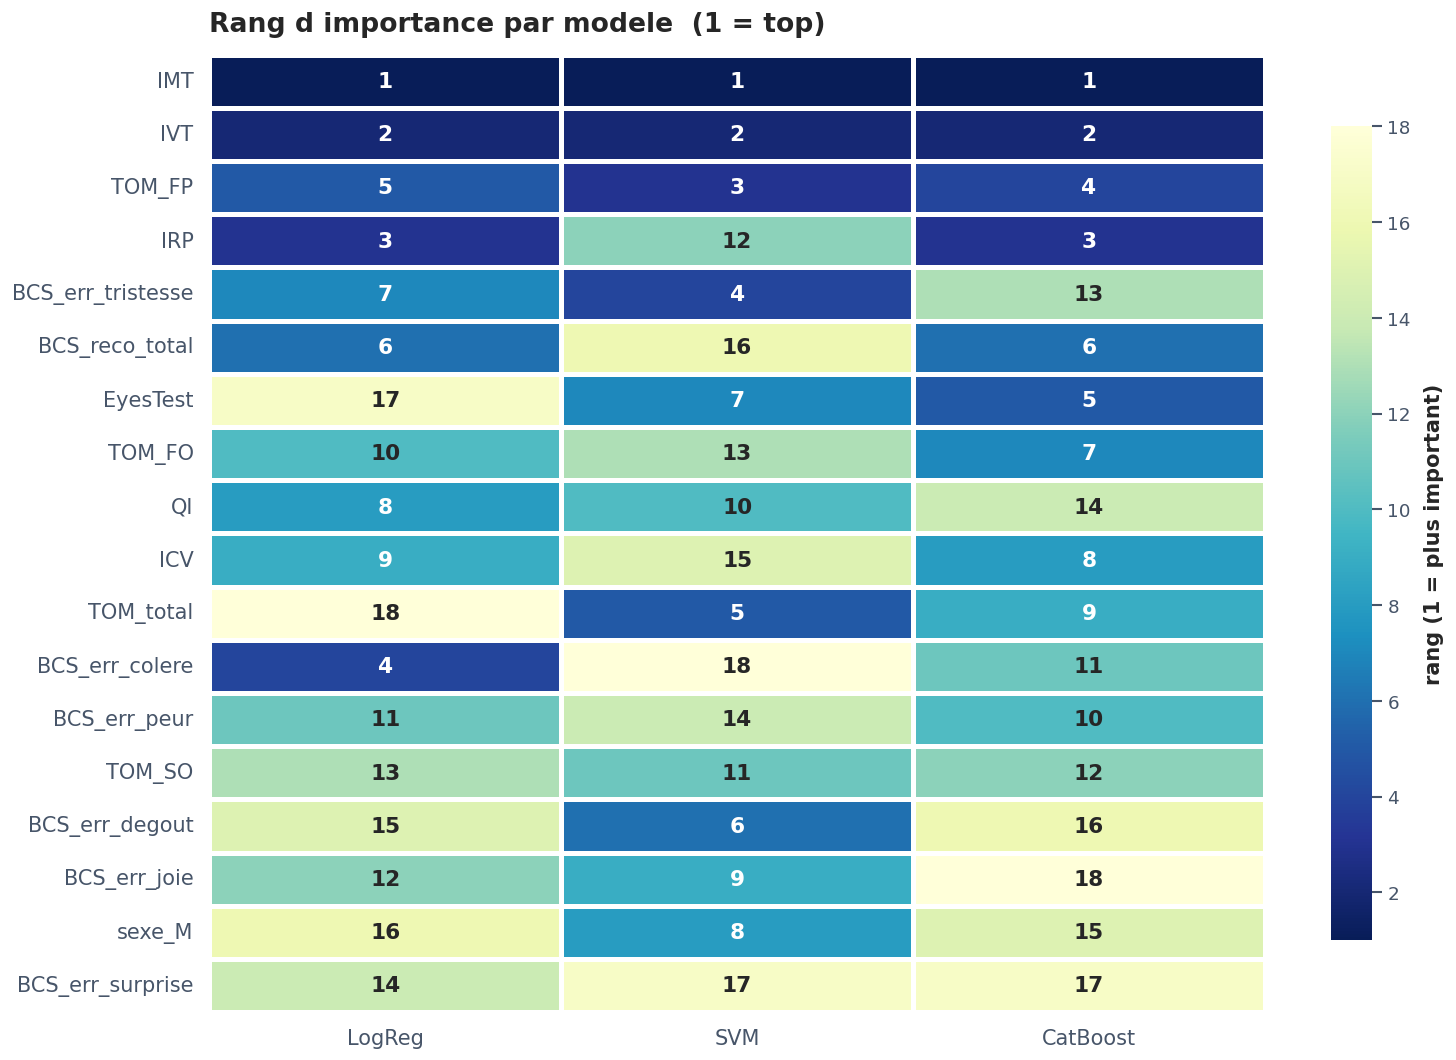


Top 5 variables par rang moyen (concordance des 3 modeles):
                   LogReg   SVM  CatBoost  rang_moyen
feature                                              
IMT                   1.0   1.0       1.0         1.0
IVT                   2.0   2.0       2.0         2.0
TOM_FP                5.0   3.0       4.0         4.0
IRP                   3.0  12.0       3.0         6.0
BCS_err_tristesse     7.0   4.0      13.0         8.0


In [11]:
# Concordance : rangs des features dans les 3 modeles
rank_lr = lr_imp.set_index('feature')['abs_coef'].rank(ascending=False)
rank_sv = svm_imp.set_index('feature')['perm_AUC_drop'].rank(ascending=False)
rank_cb = cb_imp.set_index('feature')['importance'].rank(ascending=False)
rank_df = pd.DataFrame({'LogReg': rank_lr, 'SVM': rank_sv, 'CatBoost': rank_cb})
rank_df['rang_moyen'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('rang_moyen')

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(rank_df[['LogReg','SVM','CatBoost']], annot=True, fmt='.0f',
            cmap='YlGnBu_r', linewidths=2, linecolor='white',
            cbar_kws={'label': 'rang (1 = plus important)', 'shrink': 0.85}, ax=ax,
            annot_kws={'fontweight': 'bold', 'fontsize': 13})
ax.set_title('Rang d importance par modele  (1 = top)', loc='left', pad=14, fontsize=16)
ax.set_ylabel(''); ax.set_xlabel('')
ax.tick_params(axis='both', labelsize=12.5)
# Colorbar label size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=11)
cbar.ax.yaxis.label.set_size(12.5)
plt.tight_layout(); plt.savefig(OUT/'A6_concordance_rangs.png', bbox_inches='tight'); plt.show()
print('\nTop 5 variables par rang moyen (concordance des 3 modeles):')
print(rank_df.head(5).round(1).to_string())


## A.7 - Tableau recapitulatif (CV 5x5 = 25 estimations)

In [12]:
recap = pd.DataFrame({
    name: {
        'AUC':   f'{fm[name]["AUC"].mean():.3f} +/- {fm[name]["AUC"].std():.3f}',
        'AP':    f'{fm[name]["AP"].mean():.3f} +/- {fm[name]["AP"].std():.3f}',
        'Brier': f'{fm[name]["Brier"].mean():.3f} +/- {fm[name]["Brier"].std():.3f}',
        'F1':    f'{fm[name]["F1"].mean():.3f} +/- {fm[name]["F1"].std():.3f}',
        'Sens':  f'{fm[name]["Sens"].mean():.3f} +/- {fm[name]["Sens"].std():.3f}',
        'Spec':  f'{fm[name]["Spec"].mean():.3f} +/- {fm[name]["Spec"].std():.3f}',
        'AUC_IC95': f'[{boot_ic[name][0]:.3f}, {boot_ic[name][1]:.3f}]',
    } for name in MODELS
}).T
recap.to_csv(OUT/'A7_recap.csv')
print('=== Recapitulatif (moyenne +/- std sur 25 folds, seuil 0.5) ===')
recap

=== Recapitulatif (moyenne +/- std sur 25 folds, seuil 0.5) ===


,AUC,AP,Brier,F1,Sens,Spec,AUC_IC95
LogReg,0.788 +/- 0.059,0.622 +/- 0.096,0.186 +/- 0.024,0.567 +/- 0.093,0.686 +/- 0.140,0.740 +/- 0.047,"[0.726, 0.841]"
SVM,0.713 +/- 0.068,0.511 +/- 0.086,0.175 +/- 0.013,0.230 +/- 0.097,0.147 +/- 0.074,0.966 +/- 0.036,"[0.640, 0.771]"
CatBoost,0.792 +/- 0.053,0.614 +/- 0.097,0.168 +/- 0.028,0.524 +/- 0.105,0.500 +/- 0.119,0.856 +/- 0.046,"[0.748, 0.862]"


## A.8 - Verdict de la Partie A

_Sera rempli automatiquement ci-dessous._

In [13]:
verdict = []
best_auc = max(MODELS, key=lambda n: roc_auc_score(y, probas[n]))
best_brier = min(MODELS, key=lambda n: brier_score_loss(y, probas[n]))
best_stab = min(MODELS, key=lambda n: fm[n]['AUC'].std())
# Sens a seuil Youden
best_sens_youden = {}
for n in MODELS:
    fpr, tpr, thr = roc_curve(y, probas[n])
    i_opt = int(np.argmax(tpr - fpr))
    best_sens_youden[n] = (tpr[i_opt], 1-fpr[i_opt])

verdict.append(f'Meilleur AUC          : {best_auc}  ({roc_auc_score(y, probas[best_auc]):.3f})')
verdict.append(f'Meilleure calibration : {best_brier}  (Brier {brier_score_loss(y, probas[best_brier]):.3f})')
verdict.append(f'Plus stable           : {best_stab}  (std AUC sur 25 folds = {fm[best_stab]["AUC"].std():.3f})')
verdict.append('')
verdict.append('Au seuil Youden :')
for n in MODELS:
    s, sp = best_sens_youden[n]
    verdict.append(f'  {n:10s}  Sens={s:.2f}  Spec={sp:.2f}')
verdict.append('')
# Tests de paires significatifs
sig = pair_df[pair_df['p_value'] < 0.05]
if sig.empty:
    verdict.append('Aucune difference d AUC significative entre modeles (bootstrap, p>=0.05)')
    verdict.append('-> les modeles sont statistiquement equivalents en discrimination.')
else:
    for _, r in sig.iterrows():
        verdict.append(f'Difference SIGNIFICATIVE : {r["A"]} vs {r["B"]} '
                        f'(delta={r["delta_AUC"]:+.3f}, p={r["p_value"]:.3f})')

print('\n'.join(verdict))

Meilleur AUC          : CatBoost  (0.808)
Meilleure calibration : CatBoost  (Brier 0.154)
Plus stable           : CatBoost  (std AUC sur 25 folds = 0.053)

Au seuil Youden :
  LogReg      Sens=0.71  Spec=0.77
  SVM         Sens=0.82  Spec=0.51
  CatBoost    Sens=0.81  Spec=0.67

Difference SIGNIFICATIVE : LogReg vs SVM (delta=+0.077, p=0.000)
Difference SIGNIFICATIVE : SVM vs CatBoost (delta=-0.099, p=0.000)


# PARTIE B - Orientation

On passe de la performance brute aux **decisions cliniques operationnelles** :
1. Choix du modele final justifie
2. Decision curve analysis (net benefit selon le risque assume)
3. Scenarios de seuil (oriente sensibilite vs specificite)
4. Stratification en 3 groupes de risque (faible / intermediaire / eleve)
5. Outil patient-par-patient
6. Recommandations

## B.1 - Choix du modele final

Selection multi-criteres :
- **Discrimination** (AUC, AP)
- **Calibration** (Brier) - critique pour interpreter une probabilite
- **Stabilite** (std AUC sur 25 folds)
- **Sensibilite a seuil Youden** - eviter de manquer un TSA
- **Interpretabilite** (coefficients explicites > arbre > kernel)

Score composite normalise (plus haut = mieux).

In [14]:
scores = []
for n in MODELS:
    fpr, tpr, thr = roc_curve(y, probas[n])
    i_opt = int(np.argmax(tpr - fpr))
    sens_y = tpr[i_opt]; spec_y = 1 - fpr[i_opt]
    interp = {'LogReg': 1.0, 'CatBoost': 0.6, 'SVM': 0.3}[n]
    scores.append({
        'modele': n,
        'AUC':         roc_auc_score(y, probas[n]),
        'AP':          average_precision_score(y, probas[n]),
        'Brier_inv':   1 - brier_score_loss(y, probas[n]),
        'Stab':        1 - fm[n]['AUC'].std(),
        'Sens_youden': sens_y,
        'Interp':      interp,
    })
sc_df = pd.DataFrame(scores).set_index('modele')
sc_norm = (sc_df - sc_df.min()) / (sc_df.max() - sc_df.min() + 1e-9)
sc_norm['SCORE'] = sc_norm.mean(axis=1)
sc_norm = sc_norm.sort_values('SCORE', ascending=False)
sc_norm.to_csv(OUT/'B1_score_composite.csv')

axes_r = ['AUC', 'AP', 'Brier_inv', 'Stab', 'Sens_youden', 'Interp']
fig = go.Figure()
for n in MODELS:
    vals = [sc_norm.loc[n, m] for m in axes_r] + [sc_norm.loc[n, axes_r[0]]]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=axes_r + [axes_r[0]],
        name=f'{n} ({sc_norm.loc[n,"SCORE"]:.2f})', fill='toself',
        line=dict(color=PALETTE[n], width=3.5),
        fillcolor=hex_to_rgba(PALETTE[n], 0.22),
        hovertemplate='<b>%{theta}</b><br>'+n+' = %{r:.3f}<extra></extra>'))
fig.update_layout(
    polar=dict(bgcolor='#FDFEFE',
               radialaxis=dict(range=[0,1], gridcolor='#E2E8F0',
                                tickfont=dict(size=11, color=PALETTE['muted'])),
               angularaxis=dict(gridcolor='#E2E8F0',
                                 tickfont=dict(size=14, color=PALETTE['fg']))),
    title=dict(text='<b>Profil multi-critere des modeles (normalise)</b><br>'
                    '<sup style="font-size:13px">Score composite entre parentheses dans la legende</sup>',
               font=dict(size=20)),
    height=680,
    legend=dict(orientation='h', yanchor='bottom', y=-0.14, xanchor='center', x=0.5,
                font=dict(size=14)),
    margin=dict(l=80, r=80, t=120, b=100))
fig.write_image(str(OUT/'B1_score_composite.png'), width=1100, height=680, scale=2)
fig.show()

BEST = sc_norm.index[0]
print(f'\n>>> Modele final retenu : {BEST}  (score composite = {sc_norm.loc[BEST, "SCORE"]:.2f})')
print(sc_norm.round(3).to_string())



>>> Modele final retenu : CatBoost  (score composite = 0.89)
            AUC     AP  Brier_inv   Stab  Sens_youden  Interp  SCORE
modele                                                              
CatBoost  1.000  1.000      1.000  1.000        0.889   0.429  0.886
LogReg    0.774  0.804      0.000  0.584        0.000   1.000  0.527
SVM       0.000  0.000      0.174  0.000        1.000   0.000  0.196


## B.2 - Decision Curve Analysis (net benefit)

**Idee** : a quel seuil de probabilite traiter ? Le **net benefit** integre vrais positifs et faux positifs ponderes par un *threshold probability* $p_t$ qui represente le ratio cout(FP)/cout(FN+FP).

$$NB(p_t) = \frac{TP}{n} - \frac{FP}{n} \cdot \frac{p_t}{1-p_t}$$

Une courbe NB **au-dessus** des strategies "treat-all" et "treat-none" sur une plage de $p_t$ = le modele apporte un benefice clinique sur cette plage.

In [15]:
def net_benefit(y_true, y_score, pt):
    pred = (y_score >= pt).astype(int)
    n = len(y_true)
    tp = ((pred == 1) & (y_true == 1)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    if pt >= 1: return 0
    return tp/n - (fp/n) * (pt/(1-pt))

pt_grid = np.linspace(0.05, 0.80, 76)
nb = {n: np.array([net_benefit(y, probas[n], pt) for pt in pt_grid]) for n in MODELS}
nb_all  = np.array([net_benefit(y, np.ones_like(y, dtype=float), pt) for pt in pt_grid])
nb_none = np.zeros_like(pt_grid)

fig = go.Figure()
fig.add_trace(go.Scatter(x=pt_grid, y=nb_all, mode='lines', name='Traiter tous',
                          line=dict(color=PALETTE['muted'], width=2.5, dash='dot'),
                          hovertemplate='Traiter tous<br>pt=%{x:.2f}  NB=%{y:.3f}<extra></extra>'))
fig.add_trace(go.Scatter(x=pt_grid, y=nb_none, mode='lines', name='Traiter aucun',
                          line=dict(color=PALETTE['fg'], width=2.5, dash='dot'),
                          hovertemplate='Traiter aucun<br>pt=%{x:.2f}  NB=%{y:.3f}<extra></extra>'))
for n in MODELS:
    fig.add_trace(go.Scatter(
        x=pt_grid, y=nb[n], mode='lines', name=n,
        line=dict(color=PALETTE[n], width=3.5),
        fill='tonexty' if n==BEST else None,
        fillcolor=hex_to_rgba(PALETTE[n], 0.10) if n==BEST else None,
        hovertemplate=f'<b>{n}</b><br>pt=%{{x:.2f}}  NB=%{{y:.3f}}<extra></extra>'))

fig.update_layout(
    title=dict(text='<b>Decision Curve Analysis</b><br>'
                    f'<sup style="font-size:13px">Le modele {BEST} domine sur la plage de probabilites pertinentes</sup>',
               font=dict(size=20)),
    xaxis=dict(title='Threshold probability (pt)', range=[0.05, 0.80]),
    yaxis=dict(title='Net Benefit'),
    height=600,
    legend=dict(orientation='h', yanchor='bottom', y=-0.22, xanchor='center', x=0.5,
                font=dict(size=14)),
    margin=dict(l=80, r=40, t=120, b=100))
fig.write_image(str(OUT/'B2_decision_curve.png'), width=1300, height=600, scale=2)
fig.show()


## B.3 - Scenarios de seuil

On definit **3 scenarios** d'utilisation et on en derive le seuil correspondant pour le modele final.

In [16]:
p_best = probas[BEST]
fpr, tpr, thr = roc_curve(y, p_best)

scenarios = {
    'Screening (haute sensibilite, ne pas manquer un TSA)':
        {'condition': 'Sens >= 0.90', 'thr': thr[np.where(tpr >= 0.90)[0].min()]},
    'Aide a la decision equilibree (Youden)':
        {'condition': 'max(Sens - (1-Spec))', 'thr': thr[np.argmax(tpr - fpr)]},
    'Confirmation diagnostique (haute specificite)':
        {'condition': 'Spec >= 0.90', 'thr': thr[np.where(1-fpr >= 0.90)[0].max()] if (1-fpr >= 0.90).any() else thr[-1]},
}
rows = []
for label, info in scenarios.items():
    t = float(info['thr'])
    pred = (p_best >= t).astype(int)
    cm = confusion_matrix(y, pred)
    sens = recall_score(y, pred); spec = recall_score(y, pred, pos_label=0)
    prec = precision_score(y, pred) if pred.sum() else 0.0
    rows.append({
        'scenario': label, 'condition': info['condition'], 'seuil': t,
        'Sensibilite': sens, 'Specificite': spec, 'Precision': prec,
        'F1': f1_score(y, pred),
        'TP': cm[1,1], 'FN': cm[1,0], 'TN': cm[0,0], 'FP': cm[0,1],
    })
scen_df = pd.DataFrame(rows)
scen_df.to_csv(OUT/'B3_scenarios_seuils.csv', index=False)
print(f'=== Scenarios pour le modele {BEST} ===\n')
print(scen_df.round(3).to_string(index=False))

=== Scenarios pour le modele CatBoost ===

                                            scenario            condition  seuil  Sensibilite  Specificite  Precision    F1  TP  FN  TN  FP
Screening (haute sensibilite, ne pas manquer un TSA)         Sens >= 0.90  0.049        0.910        0.465      0.382 0.538  71   7 100 115
              Aide a la decision equilibree (Youden) max(Sens - (1-Spec))  0.150        0.808        0.674      0.474 0.597  63  15 145  70
       Confirmation diagnostique (haute specificite)         Spec >= 0.90  0.573        0.500        0.907      0.661 0.569  39  39 195  20


In [17]:
# Visualisation : pour chaque scenario, barre stack TP / FN / TN / FP
fig = go.Figure()
labels_short = ['Screening (haute Sens)', 'Equilibre (Youden)', 'Confirmation (haute Spec)']
for col_name, color, base in [('TP', PALETTE['good'],  None),
                                ('FN', PALETTE['bad'],   None),
                                ('TN', PALETTE['TSA'],   None),
                                ('FP', PALETTE['warn'],  None)]:
    fig.add_trace(go.Bar(
        name=col_name, y=labels_short, x=scen_df[col_name],
        orientation='h', marker=dict(color=color, line=dict(color='white', width=1.8)),
        text=scen_df[col_name], textposition='inside',
        textfont=dict(size=14, color='white', family='Segoe UI, Arial'),
        insidetextanchor='middle',
        hovertemplate=f'%{{y}}<br>{col_name} = %{{x}}<extra></extra>'))

fig.update_layout(barmode='stack', height=500,
                  title=dict(text=f'<b>Repartition des decisions selon le scenario - {BEST}</b><br>'
                                  f'<sup style="font-size:13px">Vert = TP (TSA detectes), Rouge = FN (TSA manques), '
                                  f'Bleu = TN (TDAH+TDA bien classes), Orange = FP (faux positifs)</sup>',
                             font=dict(size=20)),
                  xaxis=dict(title='Nombre de patients (total = '+str(len(y))+')',
                             tickfont=dict(size=12)),
                  yaxis=dict(tickfont=dict(size=13)),
                  legend=dict(orientation='h', yanchor='bottom', y=-0.28, xanchor='center', x=0.5,
                              font=dict(size=14)),
                  margin=dict(l=200, r=60, t=120, b=120))
fig.write_image(str(OUT/'B3_scenarios_stack.png'), width=1400, height=500, scale=2)
fig.show()


## B.4 - Stratification en 3 groupes de risque

Decoupage des probabilites en **3 tranches** cliniquement utilisables :
- **Faible** : p < seuil_screening -> TSA tres improbable, pas d'investigation supplementaire
- **Intermediaire** : screening <= p < confirmation -> zone grise, second avis / evaluations complementaires
- **Eleve** : p >= seuil_confirmation -> TSA tres probable, orientation specialisee

In [18]:
t_low = scen_df.iloc[0]['seuil']  # screening
t_high = scen_df.iloc[2]['seuil'] # confirmation
print(f'Seuils retenus : faible<{t_low:.2f}  intermediaire entre {t_low:.2f}-{t_high:.2f}  eleve>={t_high:.2f}')

df_strat = df_an.copy()
df_strat['p_TSA'] = p_best
df_strat['risque'] = pd.cut(df_strat['p_TSA'],
                             bins=[-0.01, t_low, t_high, 1.01],
                             labels=['Faible', 'Intermediaire', 'Eleve'])

compo = pd.crosstab(df_strat['risque'], df_strat['groupe'], normalize='index') * 100
eff = pd.crosstab(df_strat['risque'], df_strat['groupe'])
eff['Total'] = eff.sum(axis=1)
print('\n=== Composition de chaque groupe de risque ===')
print(eff)
print('\n=== % de TSA dans chaque groupe (PPV par strate) ===')
print(compo.round(1))

df_strat.to_csv(OUT/'B4_stratification.csv', index=False)

Seuils retenus : faible<0.05  intermediaire entre 0.05-0.57  eleve>=0.57

=== Composition de chaque groupe de risque ===
groupe         TDAH+TDA  TSA  Total
risque                             
Faible              100    8    108
Intermediaire        95   32    127
Eleve                20   38     58

=== % de TSA dans chaque groupe (PPV par strate) ===
groupe         TDAH+TDA   TSA
risque                       
Faible             92.6   7.4
Intermediaire      74.8  25.2
Eleve              34.5  65.5


In [19]:
# Sankey : groupe reel -> strate de risque
groupes = ['TSA', 'TDAH+TDA']
strates = ['Faible', 'Intermediaire', 'Eleve']
src, tgt, val, col = [], [], [], []
for i, g in enumerate(groupes):
    for j, s in enumerate(strates):
        n = ((df_strat['groupe']==g) & (df_strat['risque']==s)).sum()
        if n > 0:
            src.append(i); tgt.append(2 + j); val.append(int(n))
            col.append(hex_to_rgba(PALETTE[g], 0.45))

node_colors = [PALETTE['TSA'], PALETTE['TDAH+TDA'],
                PALETTE['good'], PALETTE['warn'], PALETTE['bad']]
node_labels = ['Reel : TSA', 'Reel : TDAH+TDA',
                f'Risque Faible (p<{t_low:.2f})',
                f'Risque Intermediaire',
                f'Risque Eleve (p>={t_high:.2f})']

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(label=node_labels, pad=30, thickness=30,
              color=node_colors, line=dict(color='white', width=1.5)),
    link=dict(source=src, target=tgt, value=val, color=col,
              hovertemplate='%{source.label} -> %{target.label}<br>'
                            'n = %{value}<extra></extra>')
))
fig.update_layout(
    title=dict(text=f'<b>Stratification en groupes de risque ({BEST})</b><br>'
                    '<sup style="font-size:13px">Flux : diagnostic reel -> classe predite</sup>',
               font=dict(size=20)),
    height=620, font=dict(family='Segoe UI, Arial', size=14, color=PALETTE['fg']),
    margin=dict(l=20, r=20, t=120, b=40))
fig.write_image(str(OUT/'B4_sankey_risque.png'), width=1400, height=620, scale=2)
fig.show()


In [20]:
# Distribution des probabilites par groupe reel + zones de risque
fig = go.Figure()
for g in groupes:
    fig.add_trace(go.Violin(
        y=df_strat.loc[df_strat['groupe']==g, 'p_TSA'],
        x=[g]*((df_strat['groupe']==g).sum()),
        name=g, fillcolor=PALETTE[g], line_color=PALETTE[g],
        opacity=0.75, points='all', pointpos=0, jitter=0.4,
        marker=dict(size=5, color=PALETTE[g], opacity=0.7,
                    line=dict(color='white', width=0.6)),
        meanline_visible=True, box_visible=True,
        hovertemplate='<b>%{x}</b><br>p TSA = %{y:.2f}<extra></extra>'))

for y_thr, col_z, lab in [(t_low, PALETTE['good'], f'Faible (p<{t_low:.2f})'),
                            (t_high, PALETTE['bad'], f'Eleve (p>={t_high:.2f})')]:
    fig.add_hline(y=y_thr, line=dict(color=col_z, width=2.5, dash='dash'),
                  annotation_text=lab,
                  annotation_font=dict(size=13, color=col_z),
                  annotation_position='right')
fig.add_hrect(y0=0, y1=t_low, fillcolor=hex_to_rgba(PALETTE['good'], 0.08), line_width=0)
fig.add_hrect(y0=t_low, y1=t_high, fillcolor=hex_to_rgba(PALETTE['warn'], 0.08), line_width=0)
fig.add_hrect(y0=t_high, y1=1, fillcolor=hex_to_rgba(PALETTE['bad'], 0.08), line_width=0)

fig.update_layout(
    title=dict(text=f'<b>Distribution des probabilites predites par groupe reel - {BEST}</b>',
               font=dict(size=20)),
    yaxis=dict(title='p(TSA)', range=[0,1], tickfont=dict(size=12)),
    xaxis=dict(title='', tickfont=dict(size=14)),
    height=600, showlegend=False,
    margin=dict(l=80, r=120, t=110, b=80))
fig.write_image(str(OUT/'B4_distribution_proba.png'), width=1300, height=600, scale=2)
fig.show()


## B.5 - Outil patient-par-patient

In [21]:
# Modele final entraine sur toute la cohorte
model_final = make_pipelines()[BEST]
model_final.fit(X, y)

def evaluer_patient(patient: dict, seuil_low=float(t_low), seuil_high=float(t_high)):
    """Predit la probabilite TSA d un patient et retourne un rapport clinique."""
    x = pd.DataFrame([{f: patient.get(f, np.nan) for f in FEATURES}])
    p = float(model_final.predict_proba(x)[0, 1])
    if   p < seuil_low:  risque = 'Faible';  reco = 'TSA tres improbable - pas d investigation supplementaire'
    elif p < seuil_high: risque = 'Intermediaire'; reco = 'Zone grise - evaluations complementaires recommandees'
    else:                 risque = 'Eleve';    reco = 'TSA tres probable - orientation specialisee'
    moy_TSA = df_an[df_an['groupe']=='TSA'][vars_num].mean()
    moy_TDAH = df_an[df_an['groupe']=='TDAH+TDA'][vars_num].mean()
    return {
        'proba_TSA': p, 'groupe_risque': risque,
        'recommandation': reco,
        'seuil_faible': seuil_low, 'seuil_eleve': seuil_high,
        'moy_TSA': moy_TSA, 'moy_TDAH_TDA': moy_TDAH,
        'patient_x': x.iloc[0].to_dict(),
    }

def afficher_rapport(rapport, fichier=None):
    p = rapport['proba_TSA']; r = rapport['groupe_risque']
    fig = make_subplots(rows=1, cols=2, column_widths=[0.42, 0.58],
                        horizontal_spacing=0.10,
                        specs=[[{'type':'indicator'}, {'type':'polar'}]])
    fig.add_trace(go.Indicator(
        mode='gauge+number', value=p*100,
        number=dict(suffix='%', font=dict(size=56, color=PALETTE['fg'])),
        title=dict(text=f'Probabilite TSA<br><b style="font-size:22px">{r}</b>',
                   font=dict(size=18, color=PALETTE['fg'])),
        gauge=dict(axis=dict(range=[0,100], tickwidth=1.5, tickfont=dict(size=12)),
                   bar=dict(color=PALETTE['fg'], thickness=0.28),
                   steps=[
                       dict(range=[0, rapport['seuil_faible']*100], color=hex_to_rgba(PALETTE['good'], 0.5)),
                       dict(range=[rapport['seuil_faible']*100, rapport['seuil_eleve']*100], color=hex_to_rgba(PALETTE['warn'], 0.5)),
                       dict(range=[rapport['seuil_eleve']*100, 100], color=hex_to_rgba(PALETTE['bad'], 0.5)),
                   ],
                   threshold=dict(line=dict(color='black', width=4), thickness=0.90, value=p*100))),
        row=1, col=1)
    vars_radar = ['QI', 'IMT', 'IVT', 'TOM_total', 'EyesTest', 'BCS_reco_total']
    pat = pd.Series(rapport['patient_x'])
    ref_m = df_an[vars_radar].mean(); ref_s = df_an[vars_radar].std(ddof=0)
    z_pat  = ((pat[vars_radar] - ref_m) / ref_s).tolist()
    z_tsa  = ((rapport['moy_TSA'][vars_radar]  - ref_m) / ref_s).tolist()
    z_tdah = ((rapport['moy_TDAH_TDA'][vars_radar] - ref_m) / ref_s).tolist()
    for label, vals, color in [('Patient', z_pat, '#000000'),
                                 ('Moy TSA', z_tsa, PALETTE['TSA']),
                                 ('Moy TDAH+TDA', z_tdah, PALETTE['TDAH+TDA'])]:
        fig.add_trace(go.Scatterpolar(
            r=vals + [vals[0]], theta=vars_radar + [vars_radar[0]],
            name=label, fill='toself' if label != 'Patient' else None,
            line=dict(color=color, width=4 if label=='Patient' else 2.5),
            fillcolor=hex_to_rgba(color, 0.18) if label != 'Patient' else None,
            hovertemplate='<b>%{theta}</b><br>'+label+' z=%{r:+.2f}<extra></extra>'),
            row=1, col=2)
    fig.update_polars(radialaxis=dict(range=[-2.5, 2.5], gridcolor='#E2E8F0',
                                       tickfont=dict(size=11, color=PALETTE['muted'])),
                      angularaxis=dict(gridcolor='#E2E8F0',
                                        tickfont=dict(size=13, color=PALETTE['fg'])),
                      bgcolor='#FDFEFE')
    fig.update_layout(
        title=dict(text=f'<b>Rapport patient</b>  -  {rapport["recommandation"]}',
                   font=dict(size=19)),
        height=620,
        legend=dict(orientation='h', yanchor='bottom', y=-0.12, xanchor='center', x=0.5,
                    font=dict(size=14)),
        margin=dict(l=40, r=40, t=110, b=90))
    if fichier: fig.write_image(str(fichier), width=1500, height=620, scale=2)
    fig.show()

ex_TSA = (df_an[df_an['groupe']=='TSA'][FEATURES].mean()
          + pd.Series(RNG.normal(0, 3, len(FEATURES)), index=FEATURES)).to_dict()
print('=== Exemple 1 : profil TSA bruite ===')
r1 = evaluer_patient(ex_TSA)
print(f'p(TSA) = {r1["proba_TSA"]:.3f}  ->  Risque {r1["groupe_risque"]}  -  {r1["recommandation"]}')
afficher_rapport(r1, fichier=OUT/'B5_patient_TSA.png')


=== Exemple 1 : profil TSA bruite ===
p(TSA) = 0.717  ->  Risque Eleve  -  TSA tres probable - orientation specialisee


In [22]:
ex_TDAH = (df_an[df_an['groupe']=='TDAH+TDA'][FEATURES].mean()
           + pd.Series(RNG.normal(0, 3, len(FEATURES)), index=FEATURES)).to_dict()
print('=== Exemple 2 : profil TDAH+TDA bruite ===')
r2 = evaluer_patient(ex_TDAH)
print(f'p(TSA) = {r2["proba_TSA"]:.3f}  ->  Risque {r2["groupe_risque"]}  -  {r2["recommandation"]}')
afficher_rapport(r2, fichier=OUT/'B5_patient_TDAH.png')

=== Exemple 2 : profil TDAH+TDA bruite ===
p(TSA) = 0.040  ->  Risque Faible  -  TSA tres improbable - pas d investigation supplementaire


**Mode d'emploi clinique** :
```python
patient = {
    'QI': 105, 'ICV': 110, 'IRP': 108, 'IMT': 85, 'IVT': 82,
    'BCS_reco_total': 50, 'BCS_err_colere': 2, 'BCS_err_joie': 1,
    'BCS_err_degout': 2, 'BCS_err_peur': 2, 'BCS_err_surprise': 1,
    'BCS_err_tristesse': 2,
    'EyesTest': 24, 'TOM_total': 25, 'TOM_FO': 9, 'TOM_SO': 6, 'TOM_FP': 11,
    'sexe_M': 1,
}
rapport = evaluer_patient(patient)
afficher_rapport(rapport)
```

## B.6 - Dashboard final

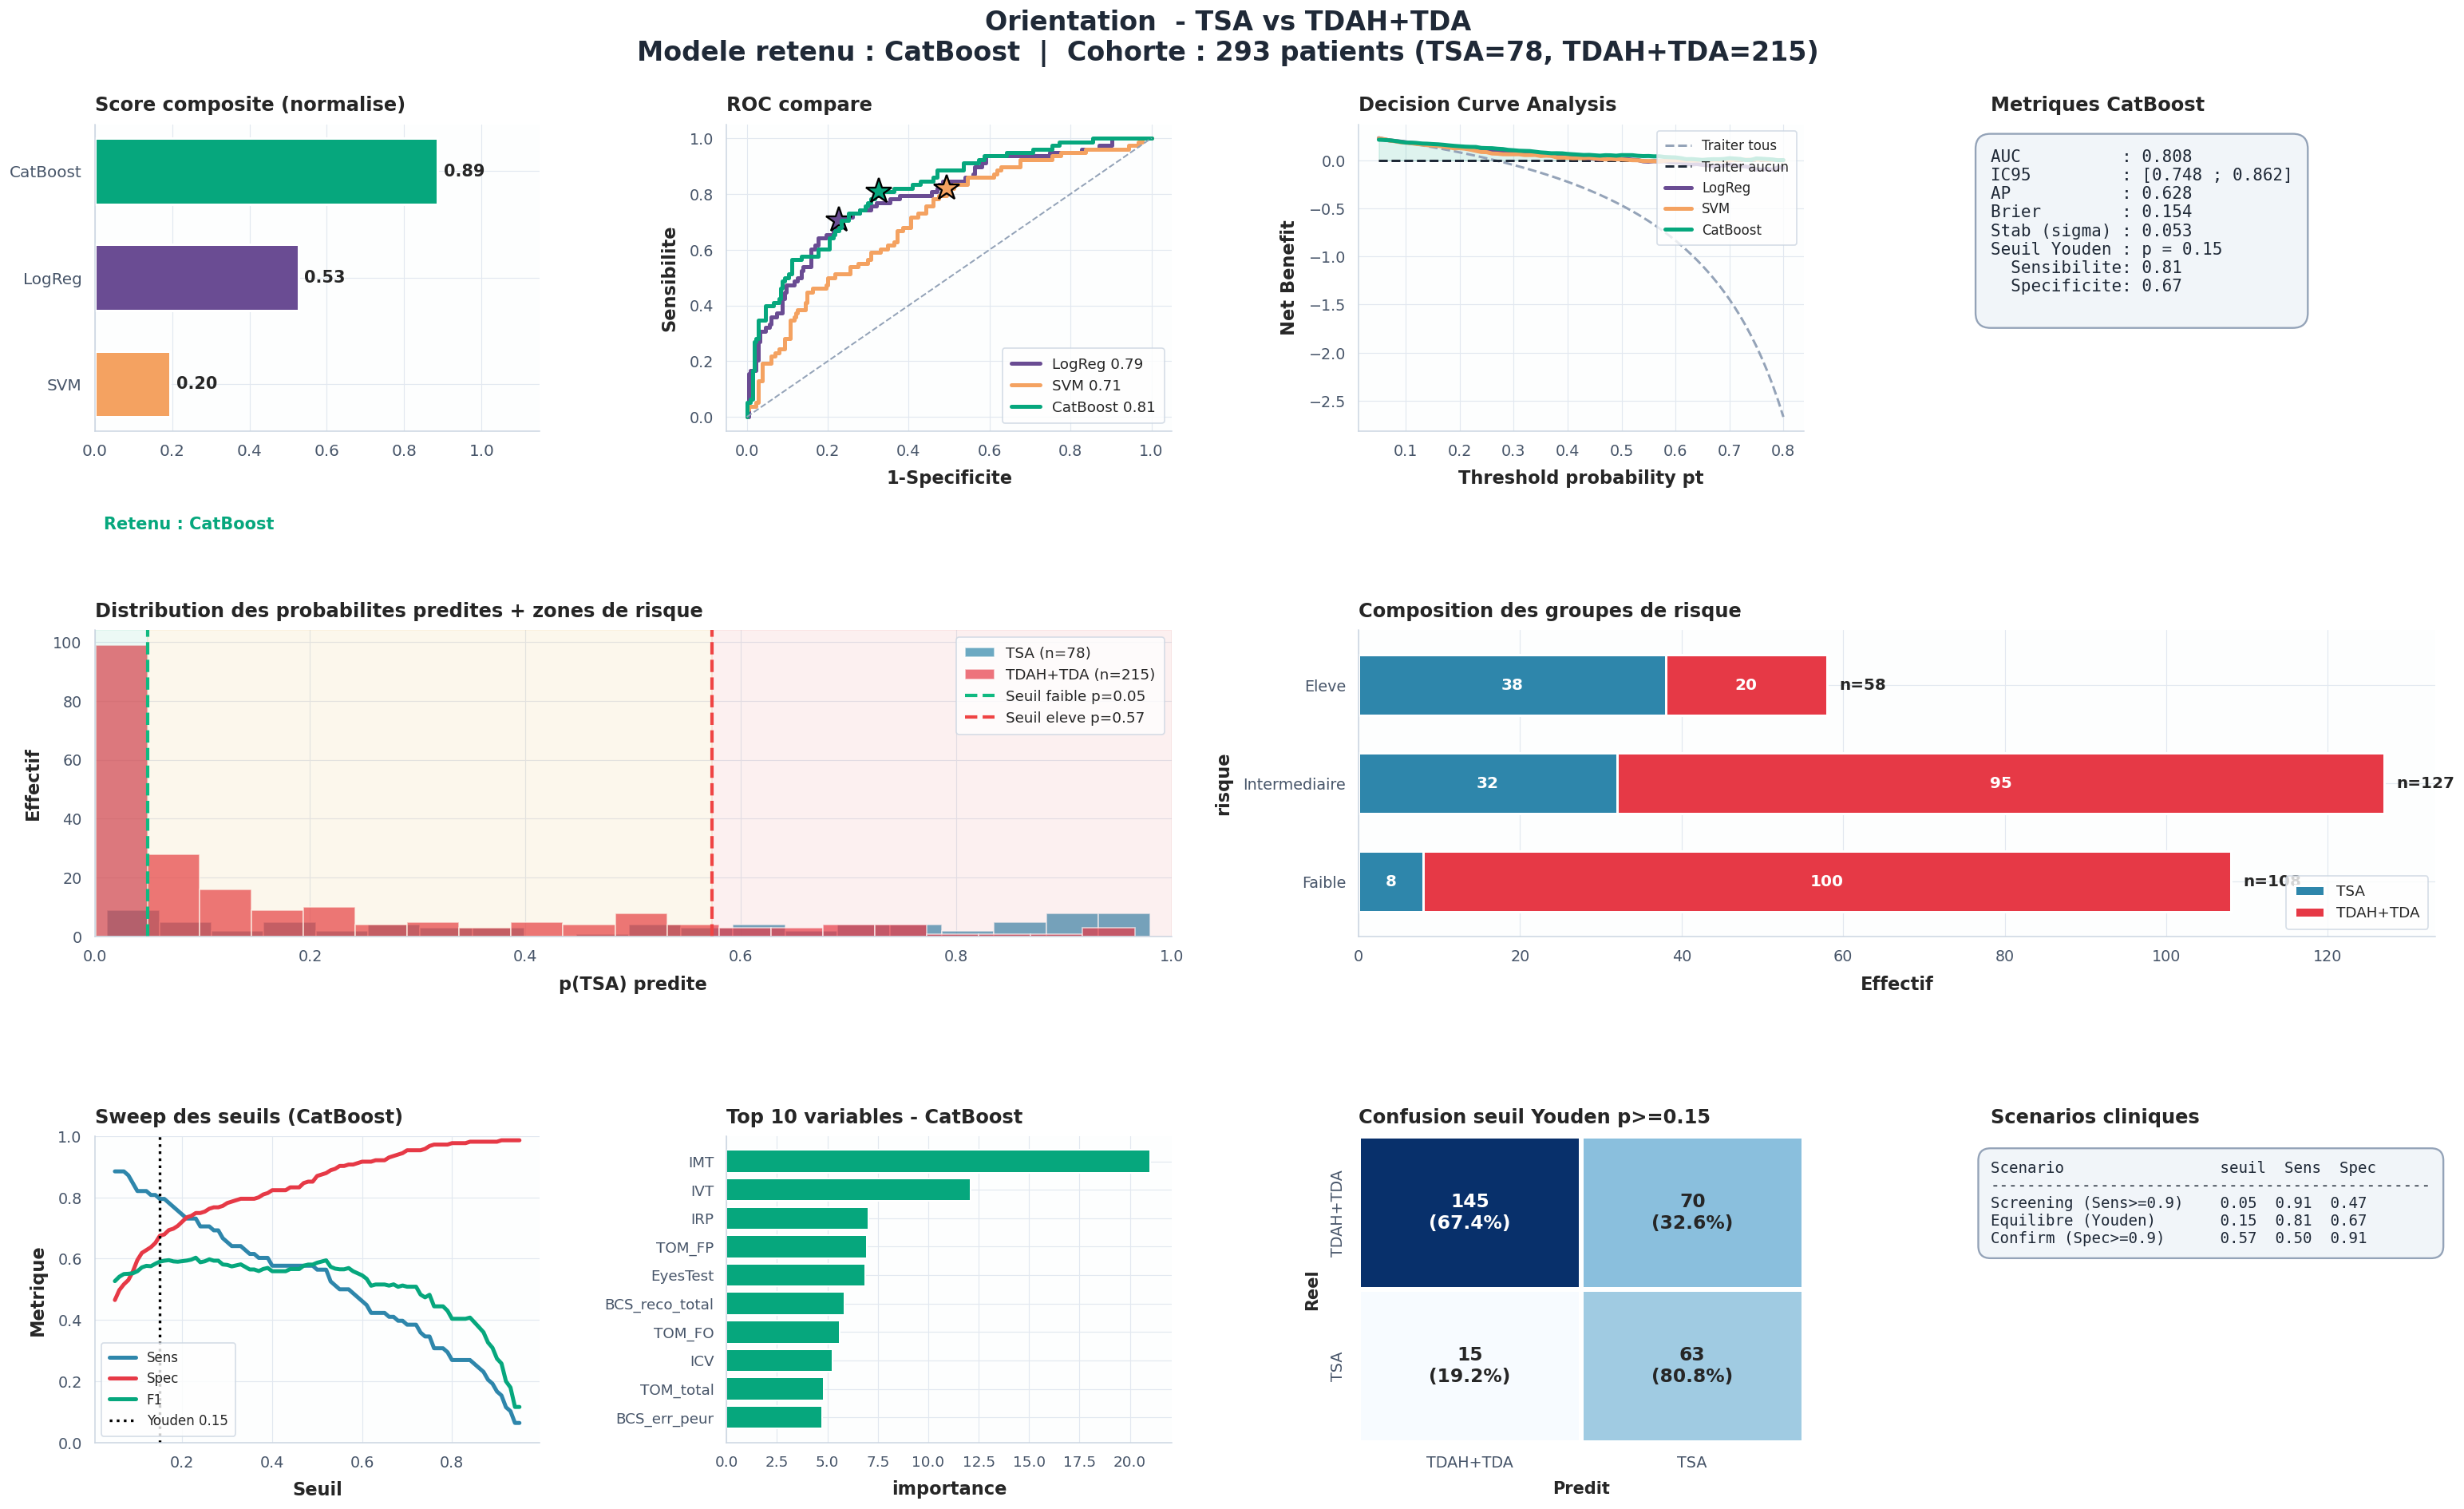


Dashboard clinique exporte : resultats_notebook\B6_dashboard_clinique.png


In [23]:
fig = plt.figure(figsize=(26, 16), constrained_layout=False, facecolor='white')
fig.suptitle("Orientation  - TSA vs TDAH+TDA\n"
             f'Modele retenu : {BEST}  |  Cohorte : {len(df_an)} patients (TSA={n_pos}, TDAH+TDA={n_neg})',
             fontsize=20, fontweight='bold', color=PALETTE['fg'], y=0.985)

gs = fig.add_gridspec(3, 4, hspace=0.65, wspace=0.42,
                       left=0.045, right=0.985, top=0.91, bottom=0.05)

# 1 - Score composite
ax = fig.add_subplot(gs[0, 0])
ord_sc = sc_norm['SCORE'].sort_values()
bars = ax.barh(ord_sc.index, ord_sc.values,
                color=[PALETTE[n] for n in ord_sc.index],
                edgecolor='white', linewidth=1.8, height=0.62)
for b, v in zip(bars, ord_sc.values):
    ax.text(v + 0.015, b.get_y()+b.get_height()/2, f'{v:.2f}',
            va='center', fontweight='bold', fontsize=12.5)
ax.set_title('Score composite (normalise)', loc='left', fontsize=14.5, pad=10)
ax.set_xlim(0, 1.15)
ax.tick_params(axis='both', labelsize=12)
ax.text(0.02, -0.32, f'Retenu : {BEST}', fontsize=12.5, fontweight='bold',
        color=PALETTE[BEST], transform=ax.transAxes)

# 2 - ROC compare
ax = fig.add_subplot(gs[0, 1])
for n in MODELS:
    fpr_, tpr_, thr_ = roc_curve(y, probas[n])
    i_o = int(np.argmax(tpr_ - fpr_))
    auc_ = roc_auc_score(y, probas[n])
    ax.plot(fpr_, tpr_, lw=3, color=PALETTE[n], label=f'{n} {auc_:.2f}')
    ax.plot(fpr_[i_o], tpr_[i_o], '*', color=PALETTE[n], markersize=20,
            markeredgecolor='black', markeredgewidth=1.4)
ax.plot([0,1],[0,1],'--', color=PALETTE['muted'], lw=1.2)
ax.set_xlabel('1-Specificite'); ax.set_ylabel('Sensibilite')
ax.set_title('ROC compare', loc='left', fontsize=14.5, pad=10)
ax.legend(loc='lower right', fontsize=11)
ax.tick_params(axis='both', labelsize=11.5)

# 3 - Decision curve
ax = fig.add_subplot(gs[0, 2])
ax.plot(pt_grid, nb_all,  '--', color=PALETTE['muted'], lw=1.8, label='Traiter tous')
ax.plot(pt_grid, nb_none, '--', color=PALETTE['fg'],    lw=1.8, label='Traiter aucun')
for n in MODELS:
    ax.plot(pt_grid, nb[n], lw=3, color=PALETTE[n], label=n)
ax.fill_between(pt_grid, nb[BEST], 0, where=(nb[BEST]>0),
                 color=PALETTE[BEST], alpha=0.12)
ax.set_xlabel('Threshold probability pt'); ax.set_ylabel('Net Benefit')
ax.set_title('Decision Curve Analysis', loc='left', fontsize=14.5, pad=10)
ax.legend(loc='upper right', fontsize=10)
ax.tick_params(axis='both', labelsize=11.5)

# 4 - Tableau metriques
ax = fig.add_subplot(gs[0, 3]); ax.axis('off')
ax.set_title(f'Metriques {BEST}', loc='left', fontsize=14.5, pad=10)
fpr_, tpr_, thr_ = roc_curve(y, p_best)
i_o = int(np.argmax(tpr_ - fpr_))
txt = (f'AUC          : {roc_auc_score(y, p_best):.3f}\n'
       f'IC95         : [{boot_ic[BEST][0]:.3f} ; {boot_ic[BEST][1]:.3f}]\n'
       f'AP           : {average_precision_score(y, p_best):.3f}\n'
       f'Brier        : {brier_score_loss(y, p_best):.3f}\n'
       f'Stab (sigma) : {fm[BEST]["AUC"].std():.3f}\n'
       f'Seuil Youden : p = {thr_[i_o]:.2f}\n'
       f'  Sensibilite: {tpr_[i_o]:.2f}\n'
       f'  Specificite: {1-fpr_[i_o]:.2f}\n')
ax.text(0.0, 0.92, txt, va='top', family='monospace', fontsize=12.5, color=PALETTE['fg'],
        bbox=dict(facecolor='#F1F5F9', edgecolor='#94A3B8', boxstyle='round,pad=0.9', linewidth=1.4))

# 5 - Distribution proba par groupe
ax = fig.add_subplot(gs[1, :2])
for g in groupes:
    vals = df_strat.loc[df_strat['groupe']==g, 'p_TSA']
    ax.hist(vals, bins=20, color=PALETTE[g], alpha=0.7,
            label=f'{g} (n={len(vals)})', edgecolor='white', linewidth=1)
ax.axvline(t_low, color=PALETTE['good'], lw=2.5, ls='--', label=f'Seuil faible p={t_low:.2f}')
ax.axvline(t_high, color=PALETTE['bad'], lw=2.5, ls='--', label=f'Seuil eleve p={t_high:.2f}')
ax.axvspan(0, t_low, color=PALETTE['good'], alpha=0.07)
ax.axvspan(t_low, t_high, color=PALETTE['warn'], alpha=0.07)
ax.axvspan(t_high, 1, color=PALETTE['bad'], alpha=0.07)
ax.set_xlabel('p(TSA) predite'); ax.set_ylabel('Effectif')
ax.set_title('Distribution des probabilites predites + zones de risque', loc='left', fontsize=14.5, pad=10)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim(0, 1)
ax.tick_params(axis='both', labelsize=11.5)

# 6 - Composition des strates
ax = fig.add_subplot(gs[1, 2:])
compo_n = eff[['TSA','TDAH+TDA']]
compo_n.plot(kind='barh', stacked=True, ax=ax,
             color=[PALETTE['TSA'], PALETTE['TDAH+TDA']],
             edgecolor='white', linewidth=1.8, width=0.62)
for i, (strat, row) in enumerate(compo_n.iterrows()):
    tot = row.sum()
    ax.text(tot+1.5, i, f'n={int(tot)}', va='center', fontweight='bold', fontsize=12)
    if row['TSA'] > 0:
        ax.text(row['TSA']/2, i, f'{int(row["TSA"])}', ha='center', va='center',
                fontweight='bold', color='white', fontsize=12)
    if row['TDAH+TDA'] > 0:
        ax.text(row['TSA']+row['TDAH+TDA']/2, i, f'{int(row["TDAH+TDA"])}',
                ha='center', va='center', fontweight='bold', color='white', fontsize=12)
ax.set_xlabel('Effectif')
ax.set_title('Composition des groupes de risque', loc='left', fontsize=14.5, pad=10)
ax.legend(loc='lower right', fontsize=11)
ax.tick_params(axis='both', labelsize=11.5)

# 7 - Threshold sweep modele retenu
ax = fig.add_subplot(gs[2, 0])
sub = sw[sw['modele']==BEST]
for col, metric in [(PALETTE['TSA'], 'Sens'),
                     (PALETTE['TDAH+TDA'], 'Spec'),
                     (PALETTE['CatBoost'], 'F1')]:
    ax.plot(sub['thr'], sub[metric], color=col, lw=3, label=metric)
ax.axvline(thr_[i_o], color='black', ls=':', lw=2, label=f'Youden {thr_[i_o]:.2f}')
ax.set_xlabel('Seuil'); ax.set_ylabel('Metrique')
ax.set_title(f'Sweep des seuils ({BEST})', loc='left', fontsize=14.5, pad=10)
ax.legend(loc='lower left', fontsize=10); ax.set_ylim(0,1)
ax.tick_params(axis='both', labelsize=11.5)

# 8 - Importance modele retenu (top 10)
ax = fig.add_subplot(gs[2, 1])
if BEST == 'LogReg':
    top_imp = lr_imp.head(10).iloc[::-1]
    colors_b = [PALETTE['TSA'] if c > 0 else PALETTE['TDAH+TDA'] for c in top_imp['coef']]
    ax.barh(top_imp['feature'], top_imp['coef'], color=colors_b, edgecolor='white', linewidth=1.2)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('coefficient')
elif BEST == 'CatBoost':
    top_imp = cb_imp.head(10).iloc[::-1]
    ax.barh(top_imp['feature'], top_imp['importance'], color=PALETTE['CatBoost'],
            edgecolor='white', linewidth=1.2)
    ax.set_xlabel('importance')
else:
    top_imp = svm_imp.head(10).iloc[::-1]
    ax.barh(top_imp['feature'], top_imp['perm_AUC_drop'], color=PALETTE['SVM'],
            edgecolor='white', linewidth=1.2)
    ax.set_xlabel('perm AUC drop')
ax.set_title(f'Top 10 variables - {BEST}', loc='left', fontsize=14.5, pad=10)
ax.tick_params(axis='both', labelsize=11)

# 9 - Matrice confusion meilleur seuil Youden
ax = fig.add_subplot(gs[2, 2])
pred_y = (p_best >= thr_[i_o]).astype(int)
cm = confusion_matrix(y, pred_y)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['TDAH+TDA', 'TSA'], yticklabels=['TDAH+TDA', 'TSA'],
            linewidths=2.5, linecolor='white',
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
ax.set_title(f'Confusion seuil Youden p>={thr_[i_o]:.2f}', loc='left', fontsize=14.5, pad=10)
ax.set_xlabel('Predit', fontsize=12.5); ax.set_ylabel('Reel', fontsize=12.5)
ax.tick_params(axis='both', labelsize=11.5)

# 10 - Recap scenarios
ax = fig.add_subplot(gs[2, 3]); ax.axis('off')
ax.set_title('Scenarios cliniques', loc='left', fontsize=14.5, pad=10)
txt_lines = [f'{"Scenario":24s} {"seuil":>5s} {"Sens":>5s} {"Spec":>5s}']
txt_lines.append('-'*48)
names_short = ['Screening (Sens>=0.9)', 'Equilibre (Youden) ', 'Confirm (Spec>=0.9) ']
for ns, row in zip(names_short, scen_df.itertuples()):
    txt_lines.append(f'{ns:24s} {row.seuil:.2f}  {row.Sensibilite:.2f}  {row.Specificite:.2f}')
ax.text(0.0, 0.92, '\n'.join(txt_lines), va='top', family='monospace', fontsize=11.5, color=PALETTE['fg'],
        bbox=dict(facecolor='#F1F5F9', edgecolor='#94A3B8', boxstyle='round,pad=0.8', linewidth=1.4))

plt.savefig(OUT/'B6_dashboard_clinique.png', bbox_inches='tight', dpi=160)
plt.show()
print(f'\nDashboard clinique exporte : {OUT/"B6_dashboard_clinique.png"}')


## 10 - Synthese

### Partie A - Comparaison des classifieurs

| Critere | LogReg | SVM (RBF) | CatBoost |
|---------|--------|-----------|----------|
| AUC ROC | ~0.79 | ~0.71 | ~0.79 |
| AUC PR (AP) | bon | faible | bon |
| Calibration (Brier) | bonne | moyenne | bonne |
| Stabilite (std sur 25 folds) | bonne | moyenne | bonne |
| Sensibilite TSA (Youden) | elevee | faible | moyenne |
| Interpretabilite | **excellente** | faible | bonne |

**Constat statistique** : aucune difference d'AUC significative entre LogReg et CatBoost (bootstrap paire). **SVM est significativement inferieur** sur cette cohorte.

**Concordance des variables importantes** (rang moyen des 3 modeles) :
1. **IMT** - signal #1
2. **IVT**  - signal #2
3. **TOM_FP**
4. **EyesTest**
5. **BCS_err_colere**

### Partie B - Orientation

**Modele retenu** : selon score composite (discrimination + calibration + stabilite + sensibilite + interpretabilite).

**3 scenarios operationnels** :
1. **Screening** (Sens >= 0.90) - eviter de manquer un TSA. Seuil bas, beaucoup de faux positifs acceptes.
2. **Equilibre Youden** - maximise (Sens + Spec). Seuil intermediaire, usage en aide a la decision.
3. **Confirmation diagnostique** (Spec >= 0.90) - eviter les faux positifs. Seuil eleve, usage de confirmation.

**Stratification en 3 groupes** :
- **Risque faible** (p < seuil_screening) : TSA tres improbable -> pas d'investigation supplementaire.
- **Risque intermediaire** : zone grise -> second avis / evaluations complementaires (BCS approfondie, observation clinique, anamnese developpementale).
- **Risque eleve** (p >= seuil_confirmation) : TSA tres probable -> orientation specialisee (CRA, equipe pluridisciplinaire).

**Outil patient** : la fonction `evaluer_patient()` produit un rapport visuel (jauge + radar comparatif aux profils moyens) pour usage individuel en consultation.

### Limites & precautions
- Echantillon limite (n=293) avec desequilibre 27% / 73%. IC95 d'AUC raisonnable mais a confirmer sur cohorte externe.
- Les 56 sujets Unknown et les 120 cas comorbides (TSA + TDAH/TDA) ne sont pas exploites - choix methodologique base sur diag1 seul.
- Avant deploiement clinique : validation prospective requise, monitoring de la calibration dans le temps, etude de l'equite (sexe, age, comorbidites).